In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.preprocessing import StandardScaler
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_numeric_std = StandardScaler().fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.776210,1,0,1,0,0,1,0.0,0,-1.101176,0.0,0.646616,-0.296907,-0.179158
1,-0.737256,0,0,0,0,1,0,0.0,1,0.105775,0.0,-1.098689,-0.763433,-0.587333
2,-0.158251,0,1,0,0,0,1,0.0,1,0.705374,1.0,-0.581431,0.191169,-0.192863
3,1.354953,0,0,0,0,1,0,0.0,1,0.550384,0.0,-1.499271,-0.705173,-0.594926
4,0.985240,0,0,0,0,1,0,0.0,1,1.233028,0.0,-1.032545,-0.613919,-0.540373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.024835,0,0,1,0,0,1,1.0,0,-1.101176,0.0,-0.312822,-0.615257,-0.488161
135,1.105290,0,0,1,0,0,1,1.0,0,-1.101176,1.0,-0.704742,0.522969,-0.099128
136,-0.354794,0,0,1,0,0,1,1.0,1,0.638406,0.0,0.535536,-0.413130,-0.282017
137,0.703351,0,0,1,0,0,1,1.0,1,2.049005,1.0,-0.642817,0.038162,-0.253362


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

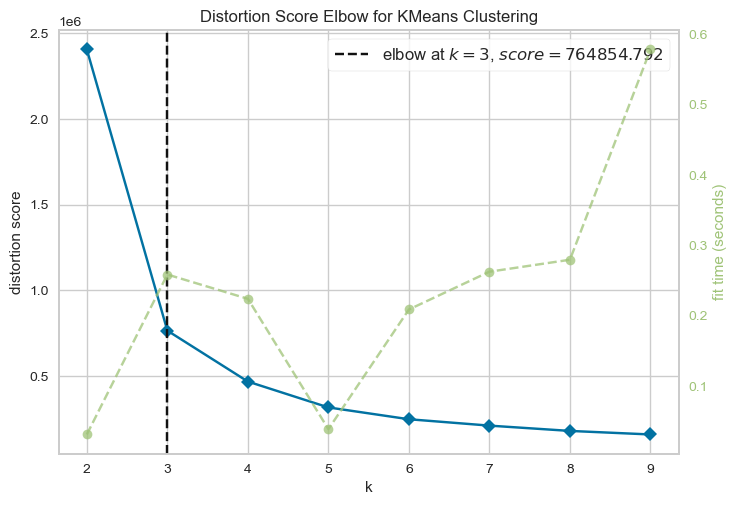

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 3  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=3)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: MTV, Coefficient: 0.47382770433825505


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: uicc8_III-IV, Coefficient: 0.739086389598171


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 2: Most important feature: hpv_related, Coefficient: -1.229060383408114


In [26]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

In [32]:
X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [33]:
# Copy the original X for later 
original_X = X.copy()

In [34]:
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Standardize X_new, the new data with the selected features only 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [35]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [36]:
X_new_std

,MTV,uicc8_III-IV,hpv_related
0,-0.296907,0.0,0.0
1,-0.763433,0.0,0.0
2,0.191169,1.0,0.0
3,-0.705173,0.0,0.0
4,-0.613919,0.0,0.0
...,...,...,...
134,-0.615257,0.0,1.0
135,0.522969,1.0,1.0
136,-0.413130,0.0,1.0
137,0.038162,1.0,1.0


In [37]:
MAASTRO_new

,MTV,uicc8_III-IV,hpv_related
0,22.841,0,1
1,5.660,1,0
2,7.791,1,0
3,7.908,1,0
4,15.237,0,1
...,...,...,...
94,6.110,1,0
95,7.182,1,0
96,16.483,1,1
97,9.981,0,1


In [38]:
MAASTRO_new_std

,MTV,uicc8_III-IV,hpv_related
0,0.810851,0,1
1,-0.465891,1,0
2,-0.307534,1,0
3,-0.298839,1,0
4,0.245788,0,1
...,...,...,...
94,-0.432451,1,0
95,-0.352789,1,0
96,0.338380,1,1
97,-0.144792,0,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [39]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:12:06,272] A new study created in memory with name: no-name-bada2bff-1809-491a-b271-fcdc5f230283


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:12:06,542] A new study created in memory with name: no-name-bdd79adb-40c0-447b-a094-5c6efc182ce7


Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:06,534] Trial 0 finished with value: 0.662902189075012 and parameters: {}. Best is trial 0 with value: 0.662902189075012.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.662902189075012], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 6, 341732), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 6, 533932), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.662902189075012


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23271689721897207
Fold 2 IBS: 0.2214079180642424
Fold 3 IBS: 0.18544750501609553
Fold 4 IBS: 0.2603487392492612
Fold 5 IBS: 0.2044138745730099
[I 2024-04-13 17:12:06,845] Trial 0 finished with value: 0.2208669868243162 and parameters: {}. Best is trial 0 with value: 0.2208669868243162.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2208669868243162], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 6, 576057), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 6, 845039), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2208669868243162


In [40]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [41]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.663
train_ibs:  0.221


#### Test

In [42]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [43]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.625
IBS score: 0.23


In [44]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [45]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [46]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:12:07,091] A new study created in memory with name: no-name-b7603210-0049-4e4a-a86d-186683e65173


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6075697211155379

[I 2024-04-13 17:12:07,275] A new study created in memory with name: no-name-cf3515b2-9113-40cc-9b2e-4a0375627ef4



Fold 2 C-index: 0.6065891472868217
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.6051502145922747
[I 2024-04-13 17:12:07,267] Trial 0 finished with value: 0.6101363898535179 and parameters: {}. Best is trial 0 with value: 0.6101363898535179.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6101363898535179], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 7, 145905), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 7, 267064), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6101363898535179


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2472470971815195
Fold 2 IBS: 0.23203988107242277
Fold 3 IBS: 0.22898186333477166
Fold 4 IBS: 0.24197477743356943
Fold 5 IBS: 0.22939558892998652
[I 2024-04-13 17:12:07,489] Trial 0 finished with value: 0.235927841590454 and parameters: {}. Best is trial 0 with value: 0.235927841590454.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.235927841590454], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 7, 315155), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 7, 488928), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.235927841590454


In [47]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [48]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.61
train_ibs:  0.236


#### Test

In [49]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [50]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.609


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [51]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [52]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:12:07,857] A new study created in memory with name: no-name-d6c91c38-8d33-4e1d-b84a-9566f63c0eb6


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411


[I 2024-04-13 17:12:08,213] A new study created in memory with name: no-name-43a30d35-46c5-4233-8d47-9c06081dceb5


Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:08,203] Trial 0 finished with value: 0.662902189075012 and parameters: {}. Best is trial 0 with value: 0.662902189075012.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.662902189075012], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 7, 906636), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 8, 203136), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.662902189075012


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23248605159547941
Fold 2 IBS: 0.22082403076777884
Fold 3 IBS: 0.18635087950235904
Fold 4 IBS: 0.2603637233096116
Fold 5 IBS: 0.2045197966240905
[I 2024-04-13 17:12:08,596] Trial 0 finished with value: 0.2209088963598639 and parameters: {}. Best is trial 0 with value: 0.2209088963598639.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2209088963598639], datetime_start=datetime.datetime(2024, 4, 13, 17, 12, 8, 280959), datetime_complete=datetime.datetime(2024, 4, 13, 17, 12, 8, 596737), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2209088963598639


In [53]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [54]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.663
train_ibs:  0.221


#### Test

In [55]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [56]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.625


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [57]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [58]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:12:08,839] A new study created in memory with name: no-name-63f9a4c5-0857-4ca7-ae8e-7af747a944f2


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:09,211] Trial 0 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.662902189075012.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:09,580] Trial 1 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.662902189075012.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:09,838] Trial 2 finished with value: 0.6279212004818561 and parameters: {'l1_ratio': 0.22692876841884668}. Bes

Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:16,088] Trial 24 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.6776130739315861}. Best is trial 0 with value: 0.662902189075012.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:16,342] Trial 25 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.8125286485497188}. Best is trial 0 with value: 0.662902189075012.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:16,608] Trial 26 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.5421167620714675}. Best is trial 0 with value: 0.66290218

Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:24,681] Trial 48 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.45330460100324665}. Best is trial 0 with value: 0.662902189075012.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:25,079] Trial 49 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.587848527895132}. Best is trial 0 with value: 0.662902189075012.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 17:12:25,471] Trial 50 finished with value: 0.662902189075012 and parameters: {'l1_ratio': 0.5027665121167861}. Best is trial 0 with value: 0.662902189075012.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.66666666

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.2324170988217969
Fold 2 IBS: 0.22072925885637448
Fold 3 IBS: 0.18617319284804684
Fold 4 IBS: 0.26041747138279475
Fold 5 IBS: 0.20444811437341145
[I 2024-04-13 17:12:40,992] Trial 0 finished with value: 0.22083702725648485 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.22083702725648485.
Fold 1 IBS: 0.23230188576016636
Fold 2 IBS: 0.2206483507325909
Fold 3 IBS: 0.18589204061837403
Fold 4 IBS: 0.2605058630462674
Fold 5 IBS: 0.20433791619596378
[I 2024-04-13 17:12:41,445] Trial 1 finished with value: 0.22073721127067247 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.22073721127067247.
Fold 1 IBS: 0.23227368592963984
Fold 2 IBS: 0.22068411843667904
Fold 3 IBS: 0.18585427845612795
Fold 4 IBS: 0.2543314451027552
Fold 5 IBS: 0.2043189171851957
[I 2024-04-13 17:12:41,763] Trial 2 finished with value: 0.21949248902207957 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.21949248902207

Fold 1 IBS: 0.2322572686495287
Fold 2 IBS: 0.22066538641962555
Fold 3 IBS: 0.18583983841411772
Fold 4 IBS: 0.253202430459015
Fold 5 IBS: 0.20430968063286767
[I 2024-04-13 17:12:49,604] Trial 25 finished with value: 0.2192549209150309 and parameters: {'l1_ratio': 0.20091168655110367}. Best is trial 25 with value: 0.2192549209150309.
Fold 1 IBS: 0.24526937938102408
Fold 2 IBS: 0.22990439134949683
Fold 3 IBS: 0.22603076847047682
Fold 4 IBS: 0.24621043609330104
Fold 5 IBS: 0.22683746570630453
[I 2024-04-13 17:12:49,791] Trial 26 finished with value: 0.2348504882001207 and parameters: {'l1_ratio': 0.06957828994833515}. Best is trial 25 with value: 0.2192549209150309.
Fold 1 IBS: 0.23234380887117756
Fold 2 IBS: 0.22072463530772968
Fold 3 IBS: 0.18604999706146838
Fold 4 IBS: 0.26046771450860723
Fold 5 IBS: 0.20438961175287632
[I 2024-04-13 17:12:50,201] Trial 27 finished with value: 0.22079515350037182 and parameters: {'l1_ratio': 0.4698787873988891}. Best is trial 25 with value: 0.2192549209

Fold 2 IBS: 0.22067963361758233
Fold 3 IBS: 0.1859016220501268
Fold 4 IBS: 0.2605167387296618
Fold 5 IBS: 0.20433170834747091
[I 2024-04-13 17:12:57,279] Trial 50 finished with value: 0.22074194028956753 and parameters: {'l1_ratio': 0.2723856910967989}. Best is trial 25 with value: 0.2192549209150309.
Fold 1 IBS: 0.2322593239162823
Fold 2 IBS: 0.22066247832699365
Fold 3 IBS: 0.18586065641862667
Fold 4 IBS: 0.2540333578210955
Fold 5 IBS: 0.2043149988725276
[I 2024-04-13 17:12:57,586] Trial 51 finished with value: 0.21942616307110513 and parameters: {'l1_ratio': 0.2198714775841745}. Best is trial 25 with value: 0.2192549209150309.
Fold 1 IBS: 0.2322318418614837
Fold 2 IBS: 0.22063728631538276
Fold 3 IBS: 0.22304972724555971
Fold 4 IBS: 0.2512518266489229
Fold 5 IBS: 0.20430172567689384
[I 2024-04-13 17:12:57,846] Trial 52 finished with value: 0.2262944815496486 and parameters: {'l1_ratio': 0.15992501757861616}. Best is trial 25 with value: 0.2192549209150309.
Fold 1 IBS: 0.23230451279737

Fold 2 IBS: 0.22065898435111228
Fold 3 IBS: 0.18586169135540465
Fold 4 IBS: 0.2539863236329387
Fold 5 IBS: 0.20431437166875002
[I 2024-04-13 17:13:05,053] Trial 75 finished with value: 0.21941567568912962 and parameters: {'l1_ratio': 0.21877076880955348}. Best is trial 67 with value: 0.21920489670620338.
Fold 1 IBS: 0.24568031542931928
Fold 2 IBS: 0.2303531895517604
Fold 3 IBS: 0.22665677584961447
Fold 4 IBS: 0.24523342654820016
Fold 5 IBS: 0.22737975512329073
[I 2024-04-13 17:13:05,206] Trial 76 finished with value: 0.23506069250043699 and parameters: {'l1_ratio': 0.05346949035039186}. Best is trial 67 with value: 0.21920489670620338.
Fold 1 IBS: 0.23229379342434273
Fold 2 IBS: 0.2206431821264083
Fold 3 IBS: 0.1858693266624902
Fold 4 IBS: 0.26051256662109146
Fold 5 IBS: 0.20432980311349155
[I 2024-04-13 17:13:05,551] Trial 77 finished with value: 0.22072973438956484 and parameters: {'l1_ratio': 0.25843946725639033}. Best is trial 67 with value: 0.21920489670620338.
Fold 1 IBS: 0.23227

In [59]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [60]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.663
train_ibs:  0.219


#### Test

In [61]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [62]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.625


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.1931546742961061)

test_ibs:  0.229


In [63]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [64]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:13:13,786] A new study created in memory with name: no-name-7a3655b7-0497-4e49-9e2d-9f51668fc387


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.603585657370518
Fold 2 C-index: 0.6182170542635659
Fold 3 C-index: 0.8085106382978723
Fold 4 C-index: 0.6825095057034221
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 17:13:18,854] Trial 0 finished with value: 0.6610195067493934 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6610195067493934.
Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6201550387596899
Fold 3 C-index: 0.8021276595744681
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.648068669527897
[I 2024-04-13 17:13:21,525] Trial 1 finished with value: 0.6621456526644081 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max

Fold 1 C-index: 0.6254980079681275
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7723404255319148
Fold 4 C-index: 0.7053231939163498
Fold 5 C-index: 0.6695278969957081
[I 2024-04-13 17:13:53,369] Trial 16 finished with value: 0.67469294364211 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 218, 'oob_score': False, 'max_samples': 0.47958988814852066, 'max_features': 'log2', 'min_weight_fraction_leaf': 9.830361885439232e-05, 'warm_start': False}. Best is trial 16 with value: 0.67469294364211.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:13:56,114] Trial 17 finished with value: 0.5 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 17, 'n_estimators': 214, 'oob_score': False, 'max_samples': 0.4139098455261398, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.4794270539064062, 'warm_start

Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.8148936170212766
Fold 4 C-index: 0.7414448669201521
Fold 5 C-index: 0.6266094420600858
[I 2024-04-13 17:14:26,082] Trial 31 finished with value: 0.6906184310571855 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 6, 'n_estimators': 371, 'oob_score': True, 'max_samples': 0.7333324554476486, 'max_features': None, 'min_weight_fraction_leaf': 0.20465791504367437, 'warm_start': True}. Best is trial 26 with value: 0.7196689834281775.
Fold 1 C-index: 0.5776892430278885
Fold 2 C-index: 0.7015503875968992
Fold 3 C-index: 0.8574468085106383
Fold 4 C-index: 0.6673003802281369
Fold 5 C-index: 0.6523605150214592
[I 2024-04-13 17:14:28,749] Trial 32 finished with value: 0.6912694668770044 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 5, 'n_estimators': 384, 'oob_score': True, 'max_samples': 0.7730125738667245

...

Fold 4 IBS: 0.23143843383566154
Fold 5 IBS: 0.2084190896186655
[I 2024-04-13 17:18:18,003] Trial 31 finished with value: 0.21674177547311918 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 20, 'min_samples_leaf': 14, 'max_depth': 16, 'n_estimators': 185, 'oob_score': False, 'max_samples': 0.7390809764326949, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.18058037259919169}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 0.23035825777478203
Fold 2 IBS: 0.21680390977031205
Fold 3 IBS: 0.19562364318706812
Fold 4 IBS: 0.23093850490126777
Fold 5 IBS: 0.20847033860808187
[I 2024-04-13 17:18:20,330] Trial 32 finished with value: 0.2164389308483024 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 19, 'min_samples_leaf': 17, 'max_depth': 14, 'n_estimators': 114, 'oob_score': False, 'max_samples': 0.8222189642278174, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13243441974214104}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 

Fold 1 IBS: 0.23611646206995734
Fold 2 IBS: 0.22754716474101708
Fold 3 IBS: 0.18556353083356267
Fold 4 IBS: 0.23303098409985498
Fold 5 IBS: 0.2061951925120693
[I 2024-04-13 17:18:55,182] Trial 47 finished with value: 0.2176906668512923 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 19, 'n_estimators': 126, 'oob_score': True, 'max_samples': 0.8796056317329229, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.13058799211116615}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 0.24648424908886213
Fold 2 IBS: 0.23205776157174432
Fold 3 IBS: 0.2295604226463578
Fold 4 IBS: 0.241609288808001
Fold 5 IBS: 0.23015683961085226
[I 2024-04-13 17:18:56,347] Trial 48 finished with value: 0.2359737123451635 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 20, 'max_depth': 15, 'n_estimators': 76, 'oob_score': False, 'max_samples': 0.7691750461428393, 'max_features': 'auto', 'min_weight_fraction_lea

Fold 5 IBS: 0.20948937079113775
[I 2024-04-13 17:19:24,879] Trial 62 finished with value: 0.21728138536937078 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 14, 'max_depth': 17, 'n_estimators': 93, 'oob_score': False, 'max_samples': 0.6651523887500298, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17280802946778745}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 0.23403655859113162
Fold 2 IBS: 0.21483274845395917
Fold 3 IBS: 0.19583485252702243
Fold 4 IBS: 0.23097087946629424
Fold 5 IBS: 0.20908610468102012
[I 2024-04-13 17:19:25,739] Trial 63 finished with value: 0.2169522287438855 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 18, 'max_depth': 15, 'n_estimators': 37, 'oob_score': False, 'max_samples': 0.7030594115689202, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.19918220326421707}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 0.23455886945241702
Fold 2 IBS: 0

Fold 1 IBS: 0.23272262794779972
Fold 2 IBS: 0.2147437480444563
Fold 3 IBS: 0.19398898162595737
Fold 4 IBS: 0.23123798791519592
Fold 5 IBS: 0.20834204559181213
[I 2024-04-13 17:20:12,502] Trial 78 finished with value: 0.2162070782250443 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 14, 'min_samples_leaf': 20, 'max_depth': 12, 'n_estimators': 324, 'oob_score': False, 'max_samples': 0.9942586658938535, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.012027927048424996}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 0.23266782435691144
Fold 2 IBS: 0.214355323667148
Fold 3 IBS: 0.1939108311675248
Fold 4 IBS: 0.2309640076200471
Fold 5 IBS: 0.20835354707488624
[I 2024-04-13 17:20:17,338] Trial 79 finished with value: 0.2160503067773035 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 14, 'min_samples_leaf': 20, 'max_depth': 12, 'n_estimators': 319, 'oob_score': False, 'max_samples': 0.9994972967722919, 'max_features': 'sqrt', 'min_weight_fraction_l

Fold 4 IBS: 0.23089905757190007
Fold 5 IBS: 0.20785790676068622
[I 2024-04-13 17:21:42,948] Trial 93 finished with value: 0.2159501470659193 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 18, 'max_depth': 15, 'n_estimators': 339, 'oob_score': True, 'max_samples': 0.9799986607658067, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.03505561647312175}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 0.23177045576272207
Fold 2 IBS: 0.21521269118811095
Fold 3 IBS: 0.19393398085106997
Fold 4 IBS: 0.23080569378771038
Fold 5 IBS: 0.20796435803083924
[I 2024-04-13 17:21:48,088] Trial 94 finished with value: 0.2159374359240905 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 18, 'max_depth': 14, 'n_estimators': 291, 'oob_score': True, 'max_samples': 0.9713954851705315, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.03562648298411432}. Best is trial 21 with value: 0.21567642057545316.
Fold 1 IBS: 0.2328

In [65]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [66]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.779
train_ibs:  0.216


#### Test

In [67]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [68]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=14, max_features='log2', max_leaf_nodes=8,
                     max_samples=0.5344520874677875, min_samples_leaf=1,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.001765235407781703,
                     n_estimators=458, random_state=123, warm_start=True)

test_cindex:  0.614


RandomSurvivalForest(max_depth=1, max_features='auto', max_leaf_nodes=17,
                     max_samples=0.8516572432333507, min_samples_leaf=18,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.10796776799958208,
                     n_estimators=103, random_state=123)

test_ibs:  0.22


In [69]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [70]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:22:17,303] A new study created in memory with name: no-name-9cd685a7-3588-4666-92bd-00fdd9c8d4a8


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.8340425531914893
Fold 4 C-index: 0.7053231939163498
Fold 5 C-index: 0.6394849785407726
[I 2024-04-13 17:22:18,824] Trial 0 finished with value: 0.6871182411178628 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6871182411178628.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:22:21,900] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.6175298804780877
Fold 2 C-index: 0.6957364341085271
Fold 3 C-index: 0.8063829787234043
Fold 4 C-index: 0.7338403041825095
Fold 5 C-index: 0.6759656652360515
[I 2024-04-13 17:22:54,161] Trial 16 finished with value: 0.7058910525457159 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 10, 'min_samples_leaf': 7, 'max_depth': 20, 'n_estimators': 237, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.8988170687511211, 'min_weight_fraction_leaf': 0.1144909881867055}. Best is trial 16 with value: 0.7058910525457159.
Fold 1 C-index: 0.649402390438247
Fold 2 C-index: 0.6686046511627907
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.7376425855513308
Fold 5 C-index: 0.6566523605150214
[I 2024-04-13 17:22:55,375] Trial 17 finished with value: 0.7033114613632652 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 6, 'max_depth': 17, 'n_estimators': 256, 'oob_score': False, 'warm_start': True, 'max_features

Fold 1 C-index: 0.5876494023904383
Fold 2 C-index: 0.7306201550387597
Fold 3 C-index: 0.8489361702127659
Fold 4 C-index: 0.8041825095057035
Fold 5 C-index: 0.7703862660944206
[I 2024-04-13 17:23:11,260] Trial 31 finished with value: 0.7483549006484175 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 12, 'min_samples_leaf': 2, 'max_depth': 15, 'n_estimators': 71, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.813911096566051, 'min_weight_fraction_leaf': 0.0014749473119459386}. Best is trial 31 with value: 0.7483549006484175.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.687984496124031
Fold 3 C-index: 0.8106382978723404
Fold 4 C-index: 0.7338403041825095
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 17:23:12,038] Trial 32 finished with value: 0.6983555541637587 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 12, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 169, 'oob_score': False, 'warm_start': True, 'max_features

...

Fold 1 IBS: 0.23518904292486092
Fold 2 IBS: 0.22075114888251696
Fold 3 IBS: 0.20772682517435992
Fold 4 IBS: 0.23058406720984062
Fold 5 IBS: 0.21201505306630658
[I 2024-04-13 17:26:56,000] Trial 30 finished with value: 0.221253227451577 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 410, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.7307512175530995, 'min_weight_fraction_leaf': 0.2917886569515737}. Best is trial 22 with value: 0.2143474326260458.
Fold 1 IBS: 0.23046348772630973
Fold 2 IBS: 0.22093682425802594
Fold 3 IBS: 0.19652208674765212
Fold 4 IBS: 0.2225753843254524
Fold 5 IBS: 0.2055444312711771
[I 2024-04-13 17:27:01,105] Trial 31 finished with value: 0.21520844286572344 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 20, 'min_samples_leaf': 7, 'max_depth': 4, 'n_estimators': 325, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.

Fold 1 IBS: 0.24000743586162873
Fold 2 IBS: 0.22447968421515324
Fold 3 IBS: 0.1895162744422513
Fold 4 IBS: 0.2165447098325547
Fold 5 IBS: 0.20282409038714036
[I 2024-04-13 17:28:50,902] Trial 45 finished with value: 0.21467443894774565 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 454, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.5998350649536632, 'min_weight_fraction_leaf': 0.01820664676789947}. Best is trial 37 with value: 0.2142512847048502.
Fold 1 IBS: 0.232095434150958
Fold 2 IBS: 0.22016430641380622
Fold 3 IBS: 0.19691149700128105
Fold 4 IBS: 0.22326525668511876
Fold 5 IBS: 0.20786466334870435
[I 2024-04-13 17:28:58,649] Trial 46 finished with value: 0.2160602315199737 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 13, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 425, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.536827178

Fold 1 IBS: 0.23412138079992628
Fold 2 IBS: 0.22024927693985058
Fold 3 IBS: 0.20327033303199818
Fold 4 IBS: 0.2283043727455095
Fold 5 IBS: 0.21103991122099702
[I 2024-04-13 17:30:32,449] Trial 60 finished with value: 0.21939705494765632 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 10, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 365, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7089374380846925, 'min_weight_fraction_leaf': 0.2583710069782479}. Best is trial 52 with value: 0.21422375574680888.
Fold 1 IBS: 0.2381890938504135
Fold 2 IBS: 0.2240568300530164
Fold 3 IBS: 0.19088751707075444
Fold 4 IBS: 0.21582633342767532
Fold 5 IBS: 0.20388198983318873
[I 2024-04-13 17:30:39,348] Trial 61 finished with value: 0.2145683528470097 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 7, 'n_estimators': 406, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.67244485

Fold 1 IBS: 0.23683690032940602
Fold 2 IBS: 0.22231562987103506
Fold 3 IBS: 0.19076101920973396
Fold 4 IBS: 0.21737473701495758
Fold 5 IBS: 0.2036055758776421
[I 2024-04-13 17:32:50,934] Trial 75 finished with value: 0.21417877246055497 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 6, 'n_estimators': 460, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.5986204048628331, 'min_weight_fraction_leaf': 0.0003332773496003971}. Best is trial 64 with value: 0.2139856746521195.
Fold 1 IBS: 0.23187967271649604
Fold 2 IBS: 0.22077868736583456
Fold 3 IBS: 0.1943400211996063
Fold 4 IBS: 0.2206274079419137
Fold 5 IBS: 0.2056455533002384
[I 2024-04-13 17:33:02,661] Trial 76 finished with value: 0.21465426850481778 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 458, 'oob_score': True, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.611923

Fold 1 IBS: 0.23902610675255456
Fold 2 IBS: 0.22257835291388675
Fold 3 IBS: 0.18960873142782264
Fold 4 IBS: 0.21808751583131206
Fold 5 IBS: 0.20153690168264407
[I 2024-04-13 17:35:27,628] Trial 90 finished with value: 0.21416752172164402 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 6, 'n_estimators': 447, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.47342815035572255, 'min_weight_fraction_leaf': 0.013478224785104942}. Best is trial 82 with value: 0.21309641695210493.
Fold 1 IBS: 0.23481628110936348
Fold 2 IBS: 0.21885243363669638
Fold 3 IBS: 0.19300919174349251
Fold 4 IBS: 0.22071293123773764
Fold 5 IBS: 0.20283752839848404
[I 2024-04-13 17:35:38,784] Trial 91 finished with value: 0.21404567322515483 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 3, 'min_samples_leaf': 3, 'max_depth': 5, 'n_estimators': 471, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.58

In [71]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [72]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.789
train_ibs:  0.213


#### Test

In [73]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [74]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=11, max_features='auto', max_leaf_nodes=16,
                   max_samples=0.7956860198583755, min_samples_leaf=1,
                   min_samples_split=2,
                   min_weight_fraction_leaf=0.0031633209119560817,
                   n_estimators=82, random_state=123, warm_start=True)

C-index score: 0.624


ExtraSurvivalTrees(max_depth=5, max_features=0.1, max_leaf_nodes=4,
                   max_samples=0.5917382095124388, min_samples_leaf=2,
                   min_samples_split=12,
                   min_weight_fraction_leaf=0.015379013990231383,
                   n_estimators=475, random_state=123, warm_start=True)

IBS: 0.227


In [75]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [76]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:37:14,093] A new study created in memory with name: no-name-918a2bf8-fb87-4b72-8032-9f40b5d8927d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:37:54,900] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:38:22,257] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:54:34,882] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6474990627764206.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:57:14,937] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-13 18:22:39,397] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 22 with value: 0.6567802711331774.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:25:38,059] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.3509209656

...

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:45:52,196] Trial 55 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.804828042321909, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.23926982708415356, 'n_estimators': 162, 'criterion': 'squared_error', 'ccp_alpha': 0.40074886285106287, 'min_weight_fraction_leaf': 0.2779066644542128, 'max_features': 'sqrt', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 4, 'max_leaf_nodes': 16, 'min_samples_leaf': 19, 'max_depth': 4}. Best is trial 45 with value: 0.23220382593437378.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:46:16,249] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6106355356441384, 'learning_rate': 0.017538150300

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:48:42,063] Trial 66 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9043457557527063, 'learning_rate': 0.08720647345857328, 'dropout_rate': 0.27193939046019544, 'n_estimators': 154, 'criterion': 'squared_error', 'ccp_alpha': 1.4111498627316026, 'min_weight_fraction_leaf': 0.23517339076530247, 'max_features': 'sqrt', 'min_impurity_decrease': 6.086951842225704e-07, 'validation_fraction': 0.9127218528145804, 'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 2}. Best is trial 63 with value: 0.23160965099500141.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:48:44,758] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8250695857763196, 'learning_rate': 0.09110863428

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:51:55,754] Trial 77 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7428517276581355, 'learning_rate': 0.07706989744762442, 'dropout_rate': 0.4476209058480567, 'n_estimators': 91, 'criterion': 'squared_error', 'ccp_alpha': 1.5888723787914292, 'min_weight_fraction_leaf': 0.16206442611838873, 'max_features': 0.1, 'min_impurity_decrease': 3.33671674086432e-07, 'validation_fraction': 0.9402673106586569, 'min_samples_split': 12, 'max_leaf_nodes': 13, 'min_samples_leaf': 17, 'max_depth': 9}. Best is trial 70 with value: 0.23128802025488318.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:52:10,884] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7715268987373948, 'learning_rate': 0.0898550375492334

Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:53:52,595] Trial 88 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6413430388178152, 'learning_rate': 0.0973528090376961, 'dropout_rate': 0.26912242502602596, 'n_estimators': 174, 'criterion': 'squared_error', 'ccp_alpha': 0.5807061908097002, 'min_weight_fraction_leaf': 0.16723537370276506, 'max_features': 0.1, 'min_impurity_decrease': 1.190634063232502e-06, 'validation_fraction': 0.8005899065401637, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 4}. Best is trial 82 with value: 0.23121807020113705.
Fold 1 IBS: 0.24223284555920863
Fold 2 IBS: 0.22672910725561854
Fold 3 IBS: 0.22011800687947283
Fold 4 IBS: 0.23752638175482968
Fold 5 IBS: 0.22363722054232635
[I 2024-04-13 20:54:10,067] Trial 89 finished with value: 0.2300487123982912 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.08109800836387941, 'dropout_rate': 0.181229994

Fold 4 IBS: 0.23846473402001322
Fold 5 IBS: 0.22485013838786852
[I 2024-04-13 20:57:37,784] Trial 99 finished with value: 0.23105394171342777 and parameters: {'subsample': 0.40791967441342253, 'learning_rate': 0.07712333235501795, 'dropout_rate': 0.19859974199600133, 'n_estimators': 143, 'criterion': 'squared_error', 'ccp_alpha': 0.004426170739568851, 'min_weight_fraction_leaf': 0.16314282359709542, 'max_features': 'log2', 'min_impurity_decrease': 5.353566353972388e-07, 'validation_fraction': 0.1604355124738367, 'min_samples_split': 11, 'max_leaf_nodes': 15, 'min_samples_leaf': 14, 'max_depth': 4}. Best is trial 91 with value: 0.22867013553580748.


* Best trial for IBS: 
 FrozenTrial(number=91, state=TrialState.COMPLETE, values=[0.22867013553580748], datetime_start=datetime.datetime(2024, 4, 13, 20, 54, 46, 213265), datetime_complete=datetime.datetime(2024, 4, 13, 20, 55, 4, 350586), params={'subsample': 0.3646963250854607, 'learning_rate': 0.09255241886126767, 'dropout_rate': 0.12363

In [77]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [78]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.682
train_ibs:  0.229


#### Test

In [79]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [80]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.0019473494055538935,
                                 criterion='squared_error',
                                 dropout_rate=0.2654836627375681,
                                 learning_rate=0.05952554251828951,
                                 max_depth=20, max_features='sqrt',
                                 max_leaf_nodes=14,
                                 min_impurity_decrease=5.608534822955176e-07,
                                 min_samples_leaf=17, min_samples_split=15,
                                 min_weight_fraction_leaf=0.3388560781293413,
                                 n_estimators=84, random_state=123,
                                 subsample=0.5073324760285014,
                                 validation_fraction=0.8254593382612642)

C-index score: 0.598


GradientBoostingSurvivalAnalysis(ccp_alpha=0.03832008885345805,
                                 criterion='squared_error',
                                 dropout_rate=0.12363276406693596,
                                 learning_rate=0.09255241886126767, max_depth=4,
                                 max_leaf_nodes=15,
                                 min_impurity_decrease=6.12703415921239e-07,
                                 min_samples_leaf=16, min_samples_split=13,
                                 min_weight_fraction_leaf=0.14198218649980035,
                                 n_estimators=143, random_state=123,
                                 subsample=0.3646963250854607,
                                 validation_fraction=0.965806971606102)

IBS: 0.222


In [81]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [82]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 20:57:44,302] A new study created in memory with name: no-name-cd3ed03f-83fb-4388-bc71-ebbb386c9891


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.5057034220532319
Fold 5 C-index: 0.6244635193133047
[I 2024-04-13 20:57:46,316] Trial 0 finished with value: 0.616584494092485 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.616584494092485.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.6244635193133047
[I 2024-04-13 20:58:04,356] Trial 1 finished with value: 0.6019525276616303 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.616584494092485.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7021276595744681
Fold 4 

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.5503875968992248
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.5475285171102662
Fold 5 C-index: 0.6051502145922747
[I 2024-04-13 21:00:08,247] Trial 19 finished with value: 0.6005607099858443 and parameters: {'subsample': 0.3739805428810522, 'dropout_rate': 0.5630287142905648, 'n_estimators': 419, 'learning_rate': 0.09857240282031608}. Best is trial 12 with value: 0.6487472583483356.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.5665399239543726
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 21:00:14,759] Trial 20 finished with value: 0.6299260682549032 and parameters: {'subsample': 0.18836019556283734, 'dropout_rate': 0.6357912569434976, 'n_estimators': 288, 'learning_rate': 0.07914328622879335}. Best is trial 12 with value: 0.6487472583483356.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7872340425531915


Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.5513307984790875
Fold 5 C-index: 0.6051502145922747
[I 2024-04-13 21:02:26,900] Trial 38 finished with value: 0.6277426122585585 and parameters: {'subsample': 0.16463489814907578, 'dropout_rate': 0.4408731973235701, 'n_estimators': 253, 'learning_rate': 0.07288612365177065}. Best is trial 12 with value: 0.6487472583483356.
Fold 1 C-index: 0.6095617529880478
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.5627376425855514
Fold 5 C-index: 0.6008583690987125
[I 2024-04-13 21:02:36,645] Trial 39 finished with value: 0.6291656119811389 and parameters: {'subsample': 0.2106866540198929, 'dropout_rate': 0.7229599989781085, 'n_estimators': 369, 'learning_rate': 0.08829012021108001}. Best is trial 12 with value: 0.6487472583483356.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7021276595744681


...

Fold 2 IBS: 0.22057781407904656
Fold 3 IBS: 0.20671489366876
Fold 4 IBS: 0.26880578387285164
Fold 5 IBS: 0.2146845956938625
[I 2024-04-13 21:12:04,144] Trial 19 finished with value: 0.2300977238815677 and parameters: {'subsample': 0.16667191735421055, 'dropout_rate': 0.994814822896155, 'n_estimators': 132, 'learning_rate': 0.016543957974820042}. Best is trial 12 with value: 0.22715634753310124.
Fold 1 IBS: 0.24253430020774683
Fold 2 IBS: 0.2200974191297583
Fold 3 IBS: 0.20886162826926094
Fold 4 IBS: 0.28082580585429884
Fold 5 IBS: 0.21293504914699288
[I 2024-04-13 21:12:04,973] Trial 20 finished with value: 0.23305084052161154 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.5777838682216713, 'n_estimators': 54, 'learning_rate': 0.03973446561107324}. Best is trial 12 with value: 0.22715634753310124.
Fold 1 IBS: 0.2440197077201151
Fold 2 IBS: 0.22840465134605595
Fold 3 IBS: 0.2233264316559437
Fold 4 IBS: 0.2451089773607419
Fold 5 IBS: 0.22578952953746065
[I 2024-04-1

Fold 3 IBS: 0.22828904898275187
Fold 4 IBS: 0.24113778463222568
Fold 5 IBS: 0.22904561058717396
[I 2024-04-13 21:13:49,671] Trial 38 finished with value: 0.235321673099969 and parameters: {'subsample': 0.24868927158147525, 'dropout_rate': 0.13272164755980653, 'n_estimators': 1, 'learning_rate': 0.06351044805702724}. Best is trial 12 with value: 0.22715634753310124.
Fold 1 IBS: 0.24431992306863995
Fold 2 IBS: 0.2260617269228717
Fold 3 IBS: 0.22077447052283328
Fold 4 IBS: 0.2634131424867631
Fold 5 IBS: 0.22200613257969815
[I 2024-04-13 21:13:52,231] Trial 39 finished with value: 0.2353150791161612 and parameters: {'subsample': 0.6034909364447238, 'dropout_rate': 0.875905443187563, 'n_estimators': 159, 'learning_rate': 0.005546073234119139}. Best is trial 12 with value: 0.22715634753310124.
Fold 1 IBS: 0.24253345534403078
Fold 2 IBS: 0.21792402728681623
Fold 3 IBS: 0.1941411165972226
Fold 4 IBS: 0.2785952666486696
Fold 5 IBS: 0.20550031046093667
[I 2024-04-13 21:14:00,206] Trial 40 finish

Fold 2 IBS: 0.2469387544676416
Fold 3 IBS: 0.1864249180529197
Fold 4 IBS: 0.31329041450555256
Fold 5 IBS: 0.20676603077985412
[I 2024-04-13 21:16:26,631] Trial 57 finished with value: 0.24526063410898374 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.4021026852858605, 'n_estimators': 312, 'learning_rate': 0.03425474905874609}. Best is trial 52 with value: 0.22691204605977844.
Fold 1 IBS: 0.29138580171899775
Fold 2 IBS: 0.24685867445796858
Fold 3 IBS: 0.19556922349741368
Fold 4 IBS: 0.3686474583006344
Fold 5 IBS: 0.20705249282551638
[I 2024-04-13 21:16:43,209] Trial 58 finished with value: 0.2619027301601061 and parameters: {'subsample': 0.285250737694168, 'dropout_rate': 0.5462080102365253, 'n_estimators': 498, 'learning_rate': 0.022232606556880842}. Best is trial 52 with value: 0.22691204605977844.
Fold 1 IBS: 0.290816781015801
Fold 2 IBS: 0.25076723333594503
Fold 3 IBS: 0.19313238891306977
Fold 4 IBS: 0.31550636895685696
Fold 5 IBS: 0.20749074306513748
[I 2024-0

Fold 1 IBS: 0.25008289819330454
Fold 2 IBS: 0.22056078957724176
Fold 3 IBS: 0.18876813041956636
Fold 4 IBS: 0.2821016415539821
Fold 5 IBS: 0.2026823685761204
[I 2024-04-13 21:19:23,872] Trial 76 finished with value: 0.22883916566404303 and parameters: {'subsample': 0.15487397231358896, 'dropout_rate': 0.34137437377843616, 'n_estimators': 370, 'learning_rate': 0.014869482006173666}. Best is trial 75 with value: 0.22651077142549153.
Fold 1 IBS: 0.25225931826326825
Fold 2 IBS: 0.21611270078320072
Fold 3 IBS: 0.20712159874520436
Fold 4 IBS: 0.30155505700575735
Fold 5 IBS: 0.20782170043492187
[I 2024-04-13 21:19:40,637] Trial 77 finished with value: 0.23697407504647047 and parameters: {'subsample': 0.9416003392097206, 'dropout_rate': 0.30582804066037816, 'n_estimators': 475, 'learning_rate': 0.007236393803954866}. Best is trial 75 with value: 0.22651077142549153.
Fold 1 IBS: 0.2531064560858067
Fold 2 IBS: 0.22095227519896365
Fold 3 IBS: 0.19172585140652434
Fold 4 IBS: 0.29139768066689675
Fo

Fold 1 IBS: 0.23694379503248378
Fold 2 IBS: 0.21883585636871603
Fold 3 IBS: 0.20469780623056885
Fold 4 IBS: 0.2664240667064087
Fold 5 IBS: 0.2125700866633854
[I 2024-04-13 21:23:07,734] Trial 95 finished with value: 0.22789432220031255 and parameters: {'subsample': 0.1006752631186829, 'dropout_rate': 0.31047762426144265, 'n_estimators': 402, 'learning_rate': 0.006457418321391658}. Best is trial 75 with value: 0.22651077142549153.
Fold 1 IBS: 0.2651014592421769
Fold 2 IBS: 0.2195386886256839
Fold 3 IBS: 0.2001929268925785
Fold 4 IBS: 0.31470728584071506
Fold 5 IBS: 0.20237369234071115
[I 2024-04-13 21:23:17,815] Trial 96 finished with value: 0.2403828105883731 and parameters: {'subsample': 0.5813829432824589, 'dropout_rate': 0.44906042172525507, 'n_estimators': 379, 'learning_rate': 0.013757450445661946}. Best is trial 75 with value: 0.22651077142549153.
Fold 1 IBS: 0.2635102711375542
Fold 2 IBS: 0.2254939559764158
Fold 3 IBS: 0.18844907141968162
Fold 4 IBS: 0.2991674737309693
Fold 5 IB

In [83]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [84]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.65
train_ibs:  0.227


#### Test

In [85]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [86]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6578418975853748,
                                              learning_rate=0.0929752118395758,
                                              n_estimators=291,
                                              random_state=123,
                                              subsample=0.11928466016861818)

C-index score: 0.625


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.34163132072065266,
                                              learning_rate=0.01345950832368604,
                                              n_estimators=364,
                                              random_state=123,
                                              subsample=0.11958558827636834)

IBS: 0.219


In [87]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [88]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.789,1.0
Randomsurvivalforest,0.779,2.0
GradientBoosting,0.682,3.0
CoxPH,0.663,5.0
CoxLasso,0.663,5.0
CoxElastic,0.663,5.0
ComponentwiseGradientBoosting,0.650,7.0
CoxRidge,0.610,8.0


In [89]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.213,1.0
Randomsurvivalforest,0.216,2.0
CoxElastic,0.219,3.0
CoxPH,0.221,4.5
CoxLasso,0.221,4.5
ComponentwiseGradientBoosting,0.227,6.0
GradientBoosting,0.229,7.0
CoxRidge,0.236,8.0


In [90]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.625,2.5
CoxLasso,0.625,2.5
CoxElastic,0.625,2.5
ComponentwiseGradientBoosting,0.625,2.5
ExtraSurvivalTrees,0.624,5.0
Randomsurvivalforest,0.614,6.0
CoxRidge,0.609,7.0
GradientBoosting,0.598,8.0


In [91]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.219,1.0
Randomsurvivalforest,0.220,2.0
GradientBoosting,0.222,3.0
ExtraSurvivalTrees,0.227,4.0
CoxRidge,0.229,6.0
CoxLasso,0.229,6.0
CoxElastic,0.229,6.0
CoxPH,0.230,8.0


In [92]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/standard/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_standard_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [93]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-13
